In [1]:
from langchain_core.tools import tool

@tool
def get_motivational_quote(topic: str):
    """Returns motivational quote for the given topic."""
    quotes = {
        "success": "Success is not final, failure is not fatal: It is the courage to continue that counts.",
        "perseverance": "Perseverance is not a long race; it is many short races one after the other.",
        "learning": "Live as if you were to die tomorrow. Learn as if you were to live forever."
    }
    return quotes.get(topic.lower(), "No quote available for this topic.")

@tool
def explain_quote(quote: str):
    """Explains a given quote"""
    return f"This quote highlights the value of {quote.split(':')[0].lower()} and encourages determination and focus."

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()

tools = [get_motivational_quote, explain_quote]
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.0).bind_tools(tools)

In [3]:
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools)

In [4]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

In [5]:
from langgraph.store.memory import InMemoryStore

in_memory_store = InMemoryStore()

In [6]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

def display_(graph):
    return display(
        Image(
            graph.get_graph().draw_mermaid_png(
                draw_method=MermaidDrawMethod.API,
            )
        )
    )

In [7]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing import List, Union

def extract_human_to_ai_sequence(messages: List[Union[HumanMessage, AIMessage, ToolMessage]]) -> List:
    # Step 1: Find the index of the last HumanMessage
    start_idx = None
    for i in reversed(range(len(messages))):
        if isinstance(messages[i], HumanMessage):
            start_idx = i
            break
    if start_idx is None:
        return []
    # Step 2: From that human message, collect all messages up to and including the next complete AI response
    result = []
    ai_message_count = 0
    for msg in messages[start_idx:]:
        result.append(msg)
        if isinstance(msg, AIMessage) and msg.content.strip():
            ai_message_count += 1
            # Stop after a full (non-empty) AI response
            break
    return result

In [8]:
import uuid
from langchain_core.runnables.config import RunnableConfig
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import HumanMessage
from langgraph.store.base import BaseStore
def call_model(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = (user_id, "memories")  # shared across threads

    recent_query = state["messages"][-1].content
    memories = store.search(namespace, query=recent_query, limit =2)
    context = "\\n".join([str(d.value) for d in memories])

    messages = [HumanMessage(content=f"Context: {context}")] + state["messages"]
    response = model.invoke(messages)

    return {"messages": response}

In [9]:
def store_memory(state:MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = (user_id, "memories")  # shared across threads
    memory_id = str(uuid.uuid4())
    memory = extract_human_to_ai_sequence(state["messages"])
    store.put(namespace, memory_id, memory)
    return {"memory": memory}

In [10]:
def should_continue(state: MessagesState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return "store_memory"

In [11]:
workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)
workflow.add_node("store_memory", store_memory)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, {"tools": "tools", "store_memory":"store_memory"})
workflow.add_edge("tools", "agent")
workflow.add_edge("store_memory", END)

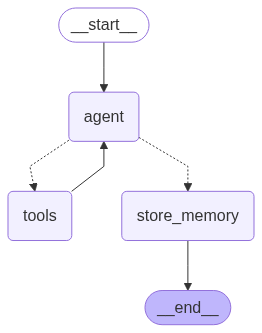

In [12]:
ltm_graph = workflow.compile(checkpointer=checkpointer, store=in_memory_store)

display(Image(ltm_graph.get_graph().draw_mermaid_png()))

In [13]:
# Invoke the graph
config = {"configurable": {"thread_id": "1", "user_id": "user_1"}}
ltm_graph.invoke({"messages": [HumanMessage(content="hi, my name is Pankaj.")]}, config)["messages"][-1].pretty_print()
ltm_graph.invoke({"messages": [HumanMessage(content="Give me a motivational quote on success")]}, config)["messages"][-1].pretty_print()

================================== Ai Message ==================================

Hi Pankaj, it's nice to meet you! How can I help you today?
================================== Ai Message ==================================

"Success is not final, failure is not fatal: It is the courage to continue that counts." This quote highlights that success is not the end, and failure is not the end either. What truly matters is the courage to keep going despite setbacks, emphasizing determination and focus.


In [14]:
config = {"configurable": {"thread_id": "2", "user_id": "user_1"}}
ltm_graph.invoke({"messages": [HumanMessage(content="what is my name?")]}, config)["messages"][-1].pretty_print()

config = {"configurable": {"thread_id": "3", "user_id": "user_1"}}
ltm_graph.invoke({"messages": [HumanMessage(content="Who am I?")]}, config)["messages"][-1].pretty_print()

================================== Ai Message ==================================

Your name is Pankaj.
================================== Ai Message ==================================

You are Pankaj.


In [15]:
config = {"configurable": {"thread_id": "4", "user_id": "user_2"}}
ltm_graph.invoke({"messages": [HumanMessage(content="what is my name?")]}, config)["messages"][-1].pretty_print()

================================== Ai Message ==================================

I do not know your name. I am a large language model, able to communicate in response to a wide range of prompts and questions, but I have no memory of past interactions.


In [16]:
config = {"configurable": {"thread_id": "2", "user_id": "user_2"}}
ltm_graph.invoke({"messages": [HumanMessage(content="what is my name?")]}, config)["messages"][-1].pretty_print()

================================== Ai Message ==================================

I do not know your name. I am a large language model, able to communicate in response to a wide range of prompts and questions, but I have no memory of past interactions.
